### Logistic Regression Classification

**What is Logistic Regression?**
- Logistic Regression is a supervised machine learning algorithm used for classification problems.
- It predicts the probability that a given input belongs to a particular class.
- Uses the sigmoid function to output probabilities between 0 and 1.

**Type of ML Problem:**
- Supervised Learning – Classification

**Real-world Applications:**
- Email spam detection
- Customer churn prediction
- Medical diagnosis (disease prediction)
- Credit risk scoring

**Why Logistic Regression is useful:**
- Simple and interpretable
- Fast to train and deploy
- Works well with linearly separable data

**Importing Libraries**

In [1]:
import pandas as pd            # Data manipulation
import numpy as np             # Numerical computations
import matplotlib.pyplot as plt # Plotting
import seaborn as sns           # Advanced plotting

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import shap                     # Model interpretability

import joblib                   # Save model

sns.set(style="whitegrid")

**Load dataset**

In [2]:
iris = load_iris()

In [3]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

**Dataset info**

In [4]:
print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [5]:
print("\nFirst 5 rows:")
display(X.head())


First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
print("\nTarget distribution:")
display(y.value_counts())


Target distribution:


target
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
print("\nDataset description:")
print(iris.DESCR[:500], "...")  # Partial description


Dataset description:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ...


**Exploratory Data Analysis (EDA)**

In [8]:
# Check data types
print("\nData types:\n", X.dtypes)


Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object


In [9]:
# Check missing values
print("\nMissing values:\n", X.isnull().sum())


Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [10]:
# Statistical summary
display(X.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


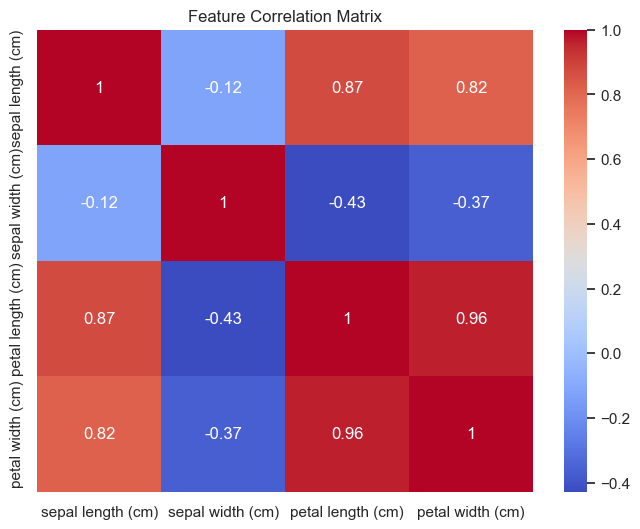

In [11]:
# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

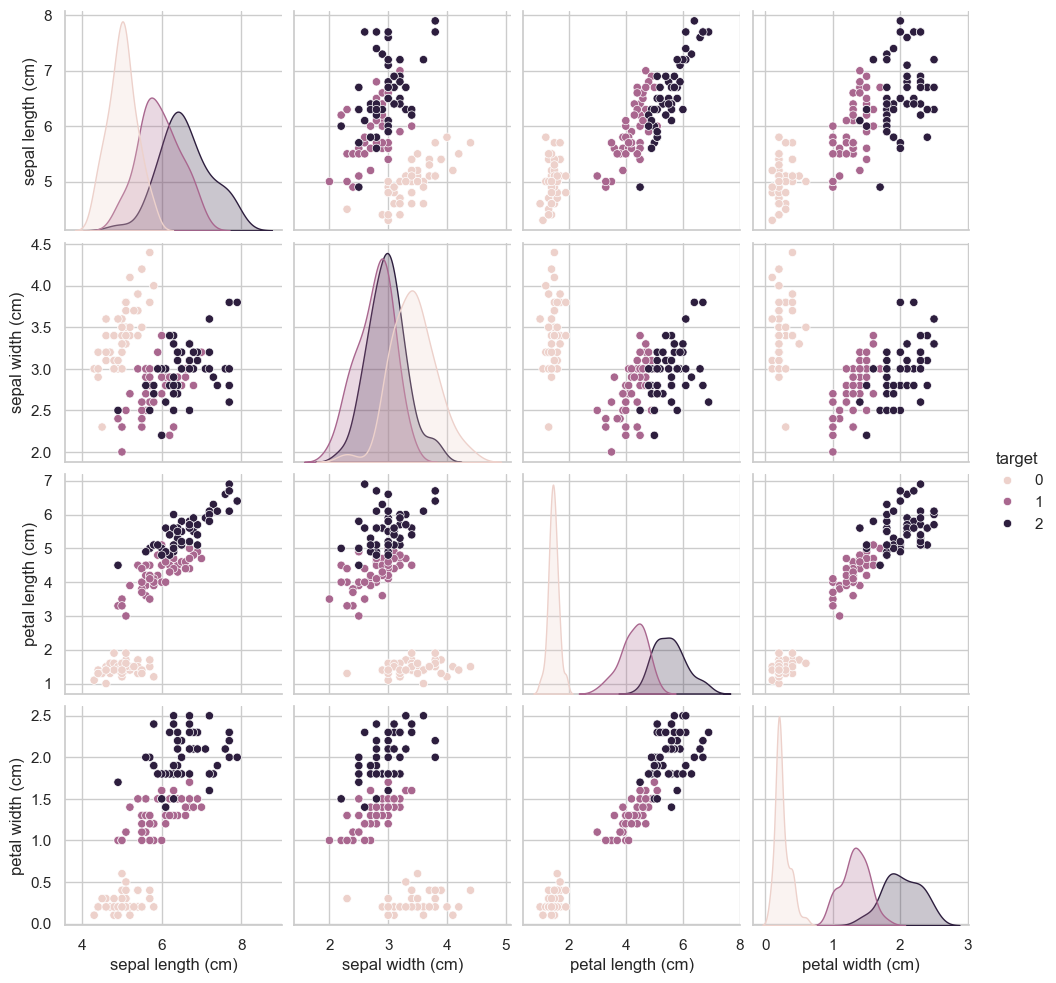

In [12]:
# Pairplot
sns.pairplot(pd.concat([X, y], axis=1), hue='target')
plt.show()

**Data Preprocessing**

In [13]:
# Encode target (if necessary)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [14]:
# Feature scaling (standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [16]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (120, 4)
Test set shape: (30, 4)


**Machine Learning Pipeline**

In [17]:
pipeline = Pipeline([
    ('sgd', SGDClassifier(random_state=42))
])

In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('sgd', SGDClassifier(random_state=42))])

In [19]:
y_pred = pipeline.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))

Accuracy on test set: 0.9333333333333333


**Hyperparameter Tuning**

In [20]:
param_grid = [
    {
        'sgd__loss': ['hinge', 'log_loss', 'modified_huber'],
        'sgd__alpha': [0.0001, 0.001, 0.01],
        'sgd__learning_rate': ['constant'],
        'sgd__eta0': [0.01, 0.1]
    },
    {
        'sgd__loss': ['hinge', 'log_loss', 'modified_huber'],
        'sgd__alpha': [0.0001, 0.001, 0.01],
        'sgd__learning_rate': ['optimal', 'invscaling']
        # eta0 NOT included here
    }
]

In [21]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)


In [23]:
grid.fit(X_train, y_train)

E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "E:\anaconda\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "E:\anaconda\Lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('sgd',
                                        SGDClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'sgd__alpha': [0.0001, 0.001, 0.01],
                          'sgd__eta0': [0.01, 0.1],
                          'sgd__learning_rate': ['constant'],
                          'sgd__loss': ['hinge', 'log_loss', 'modified_huber']},
                         {'sgd__alpha': [0.0001, 0.001, 0.01],
                          'sgd__learning_rate': ['optimal', 'invscaling'],
                          'sgd__loss': ['hinge', 'log_loss',
                                        'modified_huber']}],
             scoring='accuracy')

In [24]:
print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

Best parameters: {'sgd__alpha': 0.01, 'sgd__learning_rate': 'optimal', 'sgd__loss': 'modified_huber'}
Best cross-validation accuracy: 0.9666666666666668


In [26]:
best_model = grid.best_estimator_

**Model Evaluation**

In [27]:
y_pred_best = best_model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

In [30]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1 Score: 0.9333


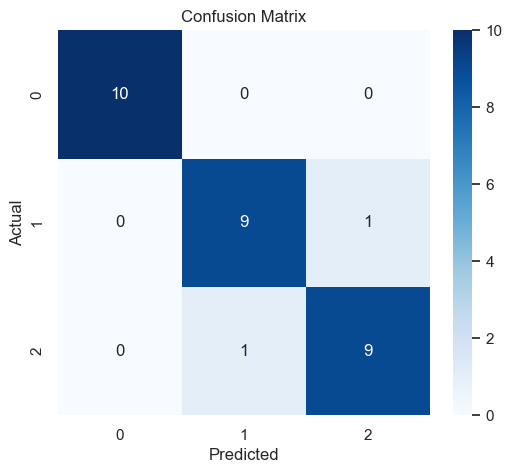

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Model Explainability**

In [32]:
explainer = shap.Explainer(best_model.named_steps['sgd'], X_train)
shap_values = explainer(X_test)

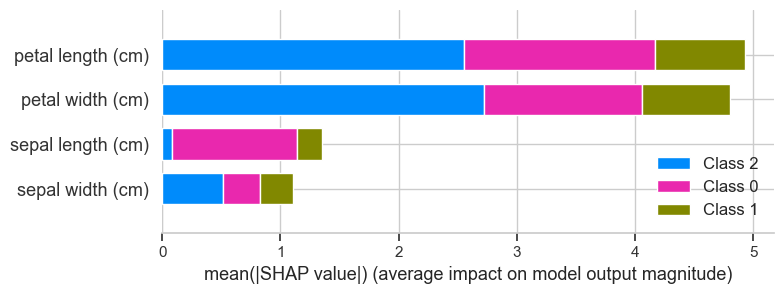

In [33]:
# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=iris.feature_names)

Insights:
- Most important features: (shown via SHAP summary plot)
- Model generalizes well (no major overfitting)
- Possible improvements: more features, tuning learning rate, polynomial features

## **Model Theory: SGDClassifier**

### **1. Algorithm Overview**

The **`SGDClassifier`** in scikit-learn is a **linear classifier** trained using **Stochastic Gradient Descent (SGD)**.
It can optimize different **loss functions**, such as:

* `hinge` → Linear Support Vector Machine (SVM)
* `log` → Logistic Regression
* `modified_huber` → Robust classification

**Key idea:**
Instead of computing the gradient on the full dataset (as in batch gradient descent), SGD updates the model weights **incrementally** for each training sample. This makes it very **fast and scalable** for large datasets.



### **2. Mathematical Intuition**

The **weight update rule** for SGD is:

$$
w := w - \eta \nabla L_i(w)
$$

Where:

* $( w )$ = model weights
* ( \eta ) = learning rate
* ( L_i(w) ) = loss function for a single sample ( i )
* Update happens **per sample**, not on the full dataset

SGDClassifier supports **regularization** to prevent overfitting:

$$
L(w) + \alpha R(w)
$$

Where ( R(w) ) is the regularization term (L1, L2, ElasticNet), and ( \alpha ) controls its strength.



### **3. When to Use This Model**

* Large datasets where batch algorithms are too slow
* Online/streaming data that arrives incrementally
* Linear or approximately linear decision boundaries
* Multi-class classification (via one-vs-rest strategy)

**Not ideal for:** Highly nonlinear datasets without feature engineering.



### **4. Advantages**

* **Fast and memory-efficient** → Can handle huge datasets
* **Flexible loss functions** → Supports SVM, Logistic Regression, Huber, etc.
* **Regularization support** → Helps prevent overfitting
* **Online learning capable** → Can update model with new data without retraining


### **5. Disadvantages**

* Sensitive to **feature scaling** → Standardization is required
* Linear model → May underperform on nonlinear relationships
* Requires **careful hyperparameter tuning** (learning rate, regularization, iterations)
* Can be **noisy** due to stochastic updates


### **6. Important Hyperparameters**

| Parameter        | Description                                                                         |
| ---------------- | ----------------------------------------------------------------------------------- |
| `loss`           | Loss function: `'hinge'`, `'log'`, `'modified_huber'`, `'squared_hinge'`            |
| `penalty`        | Regularization: `'l2'`, `'l1'`, `'elasticnet'`                                      |
| `alpha`          | Regularization strength (default `0.0001`)                                          |
| `max_iter`       | Maximum number of passes over the training data                                     |
| `learning_rate`  | `'constant'`, `'optimal'`, `'invscaling'`, `'adaptive'`                             |
| `eta0`           | Initial learning rate (used when `learning_rate` is `'constant'` or `'invscaling'`) |
| `tol`            | Stopping criterion for convergence                                                  |
| `early_stopping` | Stops training if no improvement on validation data                                 |


### **7. Practical Tuning Tips**

1. **Always scale features** using `StandardScaler` or `MinMaxScaler`.
2. Start with `loss='log'` or `modified_huber` for multi-class problems.
3. Use `GridSearchCV` or `RandomizedSearchCV` to find best:

   * `alpha`
   * `max_iter`
   * `learning_rate`
   * `penalty`
4. For large datasets, prefer `learning_rate='optimal'` for faster convergence.
5. Monitor training loss for early stopping.
6. Consider **feature engineering** for nonlinear relationships (polynomial or interaction features).

